In [1]:
# MuseumSCAT — PaliGemma-3B-mix-448 extraction pipeline
# verbatimDate + verbatimLocality, optimised for AURC (lower = better).
# Root-cause fixes: native task prefixes (no chat/JSON), 896px OCR,
# logprob×agreement×validity confidence, dual-GPU + checkpoint/resume.

In [ ]:
# ============================ CONFIG ============================
import os
import os
os.environ["HF_TOKEN"] = ""

# --- model / precision -------------------------------------------------
MODEL_ID        = "google/paligemma-3b-mix-448"  # 896px: decisive for small OCR
DTYPE           = "float16"     # T4 = Turing -> fp16 (no bf16)
USE_BOTH_GPUS   = True          # T4 x2 -> two replicas ~2x throughput (False=1 GPU)

# --- query set (quality vs speed) -------------------------------------
FAST_MODE       = False         # True: 1 date + 1 loc phrasing + OCR (~1.7x faster)
USE_LABEL_CROPS = False         # True: also OCR detected bright label rectangles
                                # (accuracy lever, +~1.5x time, safe full-image fallback)
MAX_DATE_TOK    = 24
MAX_LOC_TOK     = 24
MAX_OCR_TOK     = 64

# PaliGemma 'answer en' VQA prompts. Multiple phrasings -> agreement = a
# confidence signal. PaliGemma replies in 1-3 words, which is what we want.
DATE_PROMPTS = [
    "answer en What is the date on the label?",
    "answer en On what date was this specimen collected?",
]
LOC_PROMPTS = [
    "answer en What is the locality on the label?",
    "answer en Where was this specimen collected?",
]
OCR_PROMPT = "ocr"              # native verbatim text dump

# --- confidence --------------------------------------------------------
ROW_CONF_MODE   = "min"         # per-image conf when metric scores whole row
USE_CALIBRATION = True          # fit logistic P(correct) on labelled val if present
N_VAL           = 300           # max labelled images used for calibration

# --- run control / reliability ----------------------------------------
MAX_IMAGES       = None         # e.g. 20 for a smoke test; None = all
CHECKPOINT_EVERY = 25
EMPTY_CACHE_EVERY= 50

# --- paths (auto-discovered below) ------------------------------------
INPUT_ROOT = "/kaggle/input"
OUTPUT_DIR = "/kaggle/working"
CKPT_DIR   = os.path.join(OUTPUT_DIR, "ckpt")

if FAST_MODE:
    DATE_PROMPTS = DATE_PROMPTS[:1]
    LOC_PROMPTS  = LOC_PROMPTS[:1]
os.makedirs(CKPT_DIR, exist_ok=True)
print("Config | model:", MODEL_ID, "| dual-GPU:", USE_BOTH_GPUS,
      "| fast:", FAST_MODE, "| crops:", USE_LABEL_CROPS,
      "| queries/img:", len(DATE_PROMPTS)+len(LOC_PROMPTS)+1)

Config | model: google/paligemma-3b-mix-448 | dual-GPU: True | fast: False | crops: False | queries/img: 5


In [3]:
# ====================== ENVIRONMENT SETUP ======================
# Internet is ON. Ensure transformers is new enough for PaliGemma-mix, then
# import everything. (If your kernel already loads PaliGemma, no upgrade runs.)
import subprocess, sys
def _pip(*a):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *a], check=False)
try:
    import transformers
    from packaging import version as _v
    if _v.parse(transformers.__version__) < _v.parse("4.42.0"):
        _pip("-U", "transformers>=4.44,<4.50", "accelerate>=0.33")
except Exception:
    _pip("-U", "transformers>=4.44,<4.50", "accelerate>=0.33")

import gc, glob, json, threading, time, warnings
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageOps
warnings.filterwarnings("ignore")
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k):
        return x

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
HAS_CUDA = torch.cuda.is_available()
print("torch", torch.__version__, "| CUDA", HAS_CUDA,
      "| GPUs", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print("  gpu", i, torch.cuda.get_device_name(i))

torch 2.10.0+cu128 | CUDA True | GPUs 2
  gpu 0 Tesla T4
  gpu 1 Tesla T4


In [4]:
# =================== CORE LIBRARY (unit-tested offline) ===================
# Danish-aware parsing, collector stripping, OCR-snap, reconciliation,
# confidence blend, AURC, submission auto-mapper, logistic calibrator.
"""
museumscat_lib -- pure-Python core for the MuseumSCAT PaliGemma pipeline.
Model-free & dependency-light (stdlib + optional numpy) so it is unit-testable
without a GPU / competition data / the ML stack.  The notebook inlines these
exact functions, so testing here == testing what runs on Kaggle.
"""
import re, unicodedata
from difflib import SequenceMatcher
try:
    import numpy as np
except Exception:
    np = None

# --- 0. generic text utils -------------------------------------------------
_LEADING_JUNK = re.compile(
    r"^\s*(?:answer(?:\s*en)?|the\s+(?:date|locality|location|place)"
    r"|date|locality|location|place|it\s+is|this\s+is)\s*[:\-]?\s*",
    re.IGNORECASE)
_COLLECTOR_MARKERS = re.compile(
    r"\b(?:leg\.?|legit|lgt\.?|coll\.?|det\.?|rev\.?|vid\.?)\b.*$",
    re.IGNORECASE | re.DOTALL)
_NULLISH = {"", "-", "--", "n/a", "na", "none", "no", "unknown", "unclear",
    "not sure", "no date", "no locality", "no location", "not visible",
    "not legible", "illegible", "nothing", "missing", "ingen", "ukendt",
    "?", "??"}

def strip_accents(s: str) -> str:
    s = s.replace("\u00f8", "oe").replace("\u00d8", "Oe")
    s = s.replace("\u00e6", "ae").replace("\u00c6", "Ae")
    s = s.replace("\u00e5", "aa").replace("\u00c5", "Aa")
    nfkd = unicodedata.normalize("NFKD", s)
    return "".join(c for c in nfkd if not unicodedata.combining(c))

def clean_text(raw) -> str:
    if raw is None:
        return ""
    s = str(raw).replace("\r", " ").replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip()
    s = _LEADING_JUNK.sub("", s).strip()
    s = s.strip(" \t\"'`.,;:()[]{}<>")
    return s.strip()

def is_nullish(s: str) -> bool:
    return strip_accents(clean_text(s)).lower().strip() in _NULLISH

def _norm_key(s: str) -> str:
    s = strip_accents(clean_text(s)).lower()
    return re.sub(r"[^a-z0-9]+", "", s)

# --- 1. DATE ---------------------------------------------------------------
_MONTH_WORDS = ("januar|februar|marts|april|maj|juni|juli|august|september"
    "|oktober|november|december|jan|feb|mar|apr|jun|jul|aug|sep|sept|okt|nov"
    "|dec|january|february|march|may|june|july|october|januari|juuni")
_ROMAN = r"(?:i|ii|iii|iv|v|vi|vii|viii|ix|x|xi|xii)"
_DATE_PATTERNS = [
    re.compile(rf"\b\d{{1,2}}(?:\s*[-/]\s*\d{{1,2}})?\s*[.\-/ ]\s*{_ROMAN}\s*[.\-/ ]\s*\d{{2,4}}\b", re.I),
    re.compile(rf"\b\d{{1,2}}\.?\s*(?:{_MONTH_WORDS})\.?\s*\d{{2,4}}\b", re.I),
    re.compile(rf"\b(?:{_MONTH_WORDS}|{_ROMAN})\.?\s*\d{{4}}\b", re.I),
    re.compile(r"\b\d{1,2}\s*[./\-]\s*\d{1,2}\s*[./\-]\s*\d{2,4}\b"),
    re.compile(r"\b\d{4}\s*[./\-]\s*\d{1,2}\s*[./\-]\s*\d{1,2}\b"),
    re.compile(r"\b(?:1[789]\d{2}|20[0-2]\d)\b"),
]

def find_date(text: str):
    if not text:
        return "", 0.0
    for i, pat in enumerate(_DATE_PATTERNS):
        m = pat.search(text)
        if m:
            span = m.group(0).strip(" .,-/")
            strength = 1.0 if i <= 1 or i in (3, 4) else 0.55
            return span, strength
    return "", 0.0

def score_date(candidate: str) -> float:
    if is_nullish(candidate):
        return 0.0
    span, strength = find_date(candidate)
    if not span:
        return 0.15 if re.search(r"\d", candidate) else 0.0
    coverage = len(span) / max(len(clean_text(candidate)), 1)
    return min(1.0, strength * (0.6 + 0.4 * coverage))

def normalize_date(candidate: str, ocr_text: str = "") -> str:
    c = clean_text(candidate)
    if not is_nullish(c):
        span, _ = find_date(c)
        if span:
            return span
        if c:
            return c
    span, _ = find_date(ocr_text)
    return span

# --- 2. LOCALITY -----------------------------------------------------------
_DK_REGIONS = ["sjaelland","jylland","jutland","fyn","bornholm","lolland",
    "falster","moen","amager","laesoe","samsoe","als","langeland",
    "nordsjaelland","vestjylland","oestjylland","sydjylland","nordjylland",
    "midtjylland","sonderjylland","koebenhavn","copenhagen","danmark","denmark"]
_DK_TERMS = ["skov","soe","mose","strand","gaard","lund","bakke","hede","eng",
    "kaer","fjord","naes","plantage","have","dyrehave","aa","baek","holt",
    "toft","by","havn","vig","klit","krat","overdrev","kilde","bro","kloster",
    "slot","voldsted"]
_DK_SUFFIXES = ("koeb","koebing","koebing","lev","inge","sted","rup","toft",
    "holt","baek","gaard","borg","by")
_DK_PREPS = (" ved "," i "," paa "," naer ")
_BINOMIAL = re.compile(r"^[A-Z][a-z]{2,}\s[a-z]{3,}$")

def strip_collector(text: str) -> str:
    return _COLLECTOR_MARKERS.sub("", text).strip(" ,.;:-")

def score_locality(candidate: str) -> float:
    c = clean_text(candidate)
    if is_nullish(c):
        return 0.0
    low = strip_accents(c).lower()
    if _BINOMIAL.match(c.strip()):
        return 0.05
    if re.fullmatch(r"[\d\W]+", c):
        return 0.0
    score = 0.30
    if any(r in low for r in _DK_REGIONS):
        score += 0.45
    if any(re.search(rf"{t}\b", low) for t in _DK_TERMS):
        score += 0.25
    if low.endswith(_DK_SUFFIXES):
        score += 0.15
    if any(p in f" {low} " for p in _DK_PREPS):
        score += 0.10
    if re.match(r"[A-Z\u00c6\u00d8\u00c5][a-z\u00e6\u00f8\u00e5]+", c):
        score += 0.10
    n = len(c)
    if n < 3:
        score -= 0.30
    if n > 60:
        score -= 0.20
    return max(0.0, min(1.0, score))

def _strip_date_spans(s: str) -> str:
    """Remove any date-like span from a locality candidate (a locality never
    contains the collection date)."""
    prev = None
    while s and s != prev:
        prev = s
        span, _ = find_date(s)
        if span and score_date(span) >= 0.5:
            s = s.replace(span, " ")
        else:
            break
    return re.sub(r"\s+", " ", s).strip(" ,.;:-")

def normalize_locality(candidate: str, ocr_text: str = "") -> str:
    c = _strip_date_spans(strip_collector(clean_text(candidate)))
    if not is_nullish(c) and not _BINOMIAL.match(c):
        return c
    best, best_s = "", 0.0
    for line in re.split(r"[\n;|]+", ocr_text or ""):
        line = _strip_date_spans(strip_collector(clean_text(line)))
        s = score_locality(line)
        if s > best_s:
            best, best_s = line, s
    return best if best_s >= 0.5 else (c if not is_nullish(c) else "")

# --- 3. OCR-SNAP -----------------------------------------------------------
def ocr_snap(answer: str, ocr_text: str, min_ratio: float = 0.72) -> str:
    ans = clean_text(answer)
    if not ans or not ocr_text:
        return ans
    target = strip_accents(ans).lower()
    tokens = [w for w in re.split(r"\s+", ocr_text) if w.strip()]
    if not tokens:
        return ans
    n_ans = max(1, len(ans.split()))
    best, best_ratio = ans, min_ratio
    for wlen in range(max(1, n_ans - 1), n_ans + 3):
        for i in range(0, max(1, len(tokens) - wlen + 1)):
            cand = " ".join(tokens[i:i + wlen])
            ratio = SequenceMatcher(None, target, strip_accents(cand).lower()).ratio()
            if ratio > best_ratio:
                best, best_ratio = cand.strip(" .,;:-"), ratio
    return best

# --- 4. reconciliation + confidence ---------------------------------------
class Candidate:
    __slots__ = ("source", "text", "prob", "weight")
    def __init__(self, source, text, prob, weight=1.0):
        self.source = source; self.text = text
        self.prob = float(prob); self.weight = float(weight)

def _blend(prob: float, agreement: float, validity: float) -> float:
    agree = min(1.0, agreement / 2.0)
    return prob * (0.40 + 0.60 * agree) * (0.30 + 0.70 * validity)

def reconcile(field: str, candidates, ocr_text: str = ""):
    scorer = score_date if field == "date" else score_locality
    normer = normalize_date if field == "date" else normalize_locality
    cleaned = []
    for c in candidates:
        txt = clean_text(c.text)
        if field == "locality":
            txt = strip_collector(txt)
        if ocr_text and c.source.startswith("vqa"):
            txt = ocr_snap(txt, ocr_text)
        if is_nullish(txt):
            continue
        cleaned.append(Candidate(c.source, txt, c.prob, c.weight))
    if not cleaned:
        resc = normer("", ocr_text)
        if resc:
            v = scorer(resc)
            return dict(prediction=resc, confidence=_blend(0.30, 1.0, v),
                agreement=1.0, best_prob=0.30, validity=v, n_sources=1,
                chosen_source="ocr_rescue")
        return dict(prediction="", confidence=0.0, agreement=0.0,
            best_prob=0.0, validity=0.0, n_sources=0, chosen_source="none")
    groups = {}
    for c in cleaned:
        groups.setdefault(_norm_key(c.text), []).append(c)
    best_group, best_repr, best_score = None, None, -1.0
    for key, members in groups.items():
        agreement = sum(m.weight for m in members)
        best_prob = max(m.prob for m in members)
        rep = sorted(members, key=lambda m: (m.source.startswith("ocr"), m.prob))[-1]
        rep_text = normer(rep.text, ocr_text)
        validity = scorer(rep_text)
        gscore = _blend(best_prob, agreement, validity)
        if gscore > best_score:
            best_group, best_repr, best_score = key, rep_text, gscore
    members = groups[best_group]
    agreement = sum(m.weight for m in members)
    best_prob = max(m.prob for m in members)
    validity = scorer(best_repr)
    conf = _blend(best_prob, agreement, validity)
    return dict(prediction=best_repr, confidence=conf, agreement=agreement,
        best_prob=best_prob, validity=validity, n_sources=len(cleaned),
        chosen_source=sorted(members, key=lambda m: m.prob)[-1].source)

def combine_row_confidence(date_conf, loc_conf, mode="min"):
    if mode == "mean":
        return 0.5 * (date_conf + loc_conf)
    if mode == "prod":
        return date_conf * loc_conf
    return min(date_conf, loc_conf)

# --- 5. AURC ---------------------------------------------------------------
def risk_coverage_aurc(confidences, correct):
    import numpy as _np
    conf = _np.asarray(confidences, dtype=float)
    corr = _np.asarray(correct, dtype=float)
    n = len(conf)
    if n == 0:
        return dict(aurc=1.0, optimal_aurc=1.0, coverage=[], risk=[])
    order = _np.argsort(-conf, kind="stable")
    err = 1.0 - corr[order]
    k = _np.arange(1, n + 1)
    risk = _np.cumsum(err) / k
    oracle = 1.0 - corr[_np.argsort(-corr, kind="stable")]
    opt_risk = _np.cumsum(oracle) / k
    return dict(aurc=float(risk.mean()), optimal_aurc=float(opt_risk.mean()),
        coverage=(k / n).tolist(), risk=risk.tolist(),
        accuracy=float(corr.mean()))

# --- 6. correctness for local validation ----------------------------------
def verbatim_match(pred: str, truth: str, fuzzy: float = 0.90) -> int:
    p, t = _norm_key(pred), _norm_key(truth)
    if not t:
        return int(p == "")
    if p == t:
        return 1
    return int(SequenceMatcher(None, p, t).ratio() >= fuzzy)

# --- 7. sample_submission auto-mapper -------------------------------------
def detect_submission_format(columns):
    low = [c.lower() for c in columns]
    def find(*names):
        for nm in names:
            if nm in low:
                return columns[low.index(nm)]
        return None
    date_col = find("verbatimdate", "date", "verbatim_date")
    loc_col = find("verbatimlocality", "locality", "verbatim_locality", "location")
    conf_col = find("confidence", "conf", "score", "certainty", "probability")
    if date_col and loc_col:
        id_col = find("id","image_id","imageid","filename","image","catalognumber") or columns[0]
        return dict(kind="wide", id_col=id_col, date_col=date_col,
            loc_col=loc_col, conf_col=conf_col)
    id_col = find("row_id", "rowid", "id") or columns[0]
    pred_col = find("prediction", "value", "target", "label", "answer")
    if pred_col is None:
        rest = [c for c in columns if c not in (id_col, conf_col)]
        pred_col = rest[0] if rest else columns[-1]
    return dict(kind="long", id_col=id_col, pred_col=pred_col, conf_col=conf_col)

def _split_row_id(row_id, field_names):
    for f in field_names:
        for sep in ("_", "-", ":", "/"):
            suffix = sep + f
            if row_id.lower().endswith(suffix.lower()):
                return row_id[: -len(suffix)], f
    return row_id, field_names[0]

def build_submission_rows(sample_rows, columns, preds,
        field_names=("verbatimDate", "verbatimLocality"), row_conf_mode="min"):
    spec = detect_submission_format(columns)
    out = []
    if spec["kind"] == "wide":
        for r in sample_rows:
            iid = str(r[spec["id_col"]])
            p = preds.get(iid, {})
            d_txt, d_c = p.get(field_names[0], ("", 0.0))
            l_txt, l_c = p.get(field_names[1], ("", 0.0))
            row = dict(r)
            row[spec["date_col"]] = d_txt
            row[spec["loc_col"]] = l_txt
            if spec["conf_col"]:
                row[spec["conf_col"]] = combine_row_confidence(d_c, l_c, row_conf_mode)
            out.append(row)
    else:
        for r in sample_rows:
            rid = str(r[spec["id_col"]])
            iid, field = _split_row_id(rid, field_names)
            p = preds.get(iid, {})
            txt, c = p.get(field, ("", 0.0))
            row = dict(r)
            row[spec["pred_col"]] = txt
            if spec["conf_col"]:
                row[spec["conf_col"]] = c
            out.append(row)
    return out, spec

# --- 8. numpy-only logistic calibrator (sklearn-free fallback) -------------
def fit_logistic(X, y, iters=600, lr=0.3, l2=1e-3):
    """Tiny batch-GD logistic regression -> dict(w,b,mu,sd). Maps confidence
    FEATURES [best_prob, agreement/2, validity, len_norm] to P(prediction
    correct). No sklearn dependency."""
    import numpy as _np
    X = _np.asarray(X, dtype=float); y = _np.asarray(y, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    mu = X.mean(0); sd = X.std(0) + 1e-6
    Xn = (X - mu) / sd
    n, d = Xn.shape
    w = _np.zeros(d); b = 0.0
    for _ in range(iters):
        z = Xn @ w + b
        p = 1.0 / (1.0 + _np.exp(-z))
        g = p - y
        w -= lr * (Xn.T @ g / n + l2 * w)
        b -= lr * g.mean()
    return dict(w=w, b=b, mu=mu, sd=sd)

def predict_logistic(X, model):
    import numpy as _np
    X = _np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    Xn = (X - model["mu"]) / model["sd"]
    z = Xn @ model["w"] + model["b"]
    return 1.0 / (1.0 + _np.exp(-z))

In [5]:
# ==================== DISCOVER COMPETITION DATA ====================

IMG_EXT = (".jpg", ".jpeg", ".png", ".tif", ".tiff")

def _find(patterns):
    hits = []
    for p in patterns:
        hits += glob.glob(p, recursive=True)
    return sorted(set(hits))

def image_id(path):
    return os.path.splitext(os.path.basename(path))[0]


# --------------------------------------------------
# Index every image under INPUT_ROOT
# --------------------------------------------------

all_imgs = [
    p for p in _find([f"{INPUT_ROOT}/**/*{e}" for e in IMG_EXT])
    if p.lower().endswith(IMG_EXT)
]

id2path = {}

for p in all_imgs:
    id2path.setdefault(image_id(p), p)

print("Indexed", len(id2path), "images")


# --------------------------------------------------
# LOAD ONLY test.csv
# --------------------------------------------------

test_files = _find([
    f"{INPUT_ROOT}/**/test.csv",
    f"{INPUT_ROOT}/**/*test*.csv"
])

if len(test_files) == 0:
    raise FileNotFoundError("test.csv not found")

TEST_CSV = test_files[0]

test_df = pd.read_csv(TEST_CSV)

print("Using test.csv:", TEST_CSV)
print("Rows in test.csv:", len(test_df))


# --------------------------------------------------
# REQUIRED IDS = ONLY TEST IMAGES
# --------------------------------------------------

REQUIRED_IDS = []

for img in test_df["image_file"].astype(str):

    REQUIRED_IDS.append(image_id(img))

print("Required test images:", len(REQUIRED_IDS))


# --------------------------------------------------
# Optional labelled file (train.csv)
# --------------------------------------------------

lab = _find([
    f"{INPUT_ROOT}/**/train*.csv",
    f"{INPUT_ROOT}/**/*label*.csv",
    f"{INPUT_ROOT}/**/*metadata*.csv",
    f"{INPUT_ROOT}/**/*ground*truth*.csv"
])

labels_df = None
LABELS_CSV = None

for h in lab:

    try:

        d = pd.read_csv(h)

        cl = {c.lower() for c in d.columns}

        if any("date" in c for c in cl) and any(("local" in c or "location" in c) for c in cl):

            labels_df = d
            LABELS_CSV = h
            break

    except Exception:
        pass

print("labels:", LABELS_CSV)
print("label rows:", 0 if labels_df is None else len(labels_df))


# --------------------------------------------------
# Check for missing images
# --------------------------------------------------

missing = [i for i in REQUIRED_IDS if i not in id2path]

print("Required ids:", len(REQUIRED_IDS))
print("Missing image files:", len(missing))

Indexed 3500 images
Using test.csv: /kaggle/input/competitions/museumscat-specimen-collection-annotation-task/test.csv
Rows in test.csv: 3300
Required test images: 3300
labels: /kaggle/input/competitions/museumscat-specimen-collection-annotation-task/train.csv
label rows: 200
Required ids: 3300
Missing image files: 0


In [6]:
# ========================= IMAGE UTILITIES =========================
def load_image(path):
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)        # honour camera orientation
    return img.convert("RGB")

def find_label_crops(pil_img, max_crops=2, min_frac=0.02, max_frac=0.60):
    """Optional: return crops of bright rectangular label regions (upscaled by
    the processor to 896px -> higher effective DPI on the text). Any failure
    returns [] so the pipeline safely falls back to the full image."""
    if not USE_LABEL_CROPS:
        return []
    try:
        import cv2
        arr = np.array(pil_img.convert("L"))
        H, W = arr.shape
        _, th = cv2.threshold(arr, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
        cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        boxes = []
        for c in cnts:
            x, y, w, h = cv2.boundingRect(c)
            frac = (w * h) / float(W * H)
            ar = w / float(max(h, 1))
            if min_frac < frac < max_frac and 0.5 < ar < 9:
                boxes.append((w * h, (x, y, w, h)))
        boxes.sort(reverse=True)
        crops = []
        for _, (x, y, w, h) in boxes[:max_crops]:
            pad = int(0.05 * max(w, h))
            crops.append(pil_img.crop((max(0, x - pad), max(0, y - pad),
                                       min(pil_img.width, x + w + pad),
                                       min(pil_img.height, y + h + pad))))
        return crops
    except Exception:
        return []

In [7]:
# ==================== LOAD PALIGEMMA REPLICA(S) ====================
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor

TORCH_DTYPE = getattr(torch, DTYPE) if HAS_CUDA else torch.float32
print("loading processor ...")
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)
EOS_ID = processor.tokenizer.eos_token_id

def _load(device_index):
    m = PaliGemmaForConditionalGeneration.from_pretrained(
        MODEL_ID, torch_dtype=TORCH_DTYPE,
        device_map={"": device_index} if HAS_CUDA else None,
        low_cpu_mem_usage=True)
    return m.eval()

n_gpu = torch.cuda.device_count()
replicas = []                                   # list of (model, device_str)
if HAS_CUDA and USE_BOTH_GPUS and n_gpu >= 2:
    replicas = [(_load(0), "cuda:0"), (_load(1), "cuda:1")]
elif HAS_CUDA:
    replicas = [(_load(0), "cuda:0")]
else:
    replicas = [(_load("cpu"), "cpu")]
torch.cuda.empty_cache() if HAS_CUDA else None
print(f"loaded {len(replicas)} replica(s):", [d for _, d in replicas])
if HAS_CUDA:
    for i in range(n_gpu):
        print(f"  gpu{i} mem {torch.cuda.memory_allocated(i)/1e9:.1f}GB alloc")

loading processor ...


preprocessor_config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

loaded 2 replica(s): ['cuda:0', 'cuda:1']
  gpu0 mem 5.8GB alloc
  gpu1 mem 5.8GB alloc


In [8]:
# ==================== INFERENCE PRIMITIVES ====================
IMG_TOKEN = "<image>"

@torch.inference_mode()
def run_query(model, device, image, task, max_new_tokens):
    """One PaliGemma call. Returns (text, geomean_prob, n_tokens).
    geomean_prob = exp(mean per-token log-prob of the greedy answer) in (0,1]."""
    try:
        inputs = processor(images=image, text= "<image>\n" + task, return_tensors="pt")
    except Exception:
        # some transformers versions want an explicit <image> placeholder
        inputs = processor(images=image, text= "<image>\n" + IMG_TOKEN + task, return_tensors="pt")
    inputs = inputs.to(device)
    if "pixel_values" in inputs:                       # match model precision
        inputs["pixel_values"] = inputs["pixel_values"].to(TORCH_DTYPE)
    in_len = inputs["input_ids"].shape[-1]
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                         do_sample=False, num_beams=1,
                         return_dict_in_generate=True, output_scores=True)
    gen_ids = out.sequences[0][in_len:]
    scores = out.scores
    logps = []
    for step in range(min(len(scores), len(gen_ids))):
        tid = int(gen_ids[step])
        if tid == EOS_ID:
            break
        lp = torch.log_softmax(scores[step][0].float(), dim=-1)
        logps.append(float(lp[tid]))
    text = processor.decode(gen_ids, skip_special_tokens=True).strip()
    geomean = float(np.exp(np.mean(logps))) if logps else 0.0
    del inputs, out, gen_ids, scores
    return text, geomean, len(logps)

def field_features(row, field):
    """Feature vector for the confidence calibrator (also used at apply-time)."""
    if field == "date":
        return [float(row.get("date_prob", 0.0)), float(row.get("date_agree", 0.0)) / 2.0,
                float(row.get("date_valid", 0.0)),
                min(len(str(row.get("verbatimDate", ""))), 40) / 40.0]
    return [float(row.get("loc_prob", 0.0)), float(row.get("loc_agree", 0.0)) / 2.0,
            float(row.get("loc_valid", 0.0)),
            min(len(str(row.get("verbatimLocality", ""))), 40) / 40.0]

In [9]:
# ====================== PER-IMAGE PIPELINE ======================
def _empty_record(iid, err=""):
    return dict(id=iid, verbatimDate="", date_conf=0.0, date_prob=0.0,
                date_agree=0.0, date_valid=0.0, verbatimLocality="",
                loc_conf=0.0, loc_prob=0.0, loc_agree=0.0, loc_valid=0.0,
                ocr="", n_queries=0, error=err)

def process_image(iid, model, device):
    """Run the query ensemble for one image and reconcile -> one record."""
    path = id2path.get(iid)
    if path is None:
        return _empty_record(iid, "no_file")
    try:
        img = load_image(path)
    except Exception as e:
        return _empty_record(iid, f"load:{type(e).__name__}")

    views = [("full", img)] + [(f"crop{i}", c)
                               for i, c in enumerate(find_label_crops(img))]
    date_cands, loc_cands, ocr_parts, nq = [], [], [], 0
    try:
        for tag, im in views:
            octxt, op, _ = run_query(model, device, im, OCR_PROMPT, MAX_OCR_TOK); nq += 1
            if octxt:
                ocr_parts.append(octxt)
                ds, _ = find_date(octxt)
                if ds:
                    date_cands.append(Candidate(f"ocr_{tag}", ds, max(op, 0.35)))
                lz = normalize_locality("", octxt)
                if lz:
                    loc_cands.append(Candidate(f"ocr_{tag}", lz, max(op, 0.35)))
            if tag != "full":
                continue                                 # VQA only on full view
            for j, pr in enumerate(DATE_PROMPTS):
                t, p, _ = run_query(model, device, im, pr, MAX_DATE_TOK); nq += 1
                if t:
                    date_cands.append(Candidate(f"vqa_date{j}", t, p))
            for j, pr in enumerate(LOC_PROMPTS):
                t, p, _ = run_query(model, device, im, pr, MAX_LOC_TOK); nq += 1
                if t:
                    loc_cands.append(Candidate(f"vqa_loc{j}", t, p))
    except Exception as e:
        if nq == 0:
            return _empty_record(iid, f"infer:{type(e).__name__}")

    ocr_text = "  ".join(ocr_parts)
    d = reconcile("date", date_cands, ocr_text)
    l = reconcile("locality", loc_cands, ocr_text)
    return dict(id=iid,
                verbatimDate=d["prediction"], date_conf=d["confidence"],
                date_prob=d["best_prob"], date_agree=d["agreement"],
                date_valid=d["validity"],
                verbatimLocality=l["prediction"], loc_conf=l["confidence"],
                loc_prob=l["best_prob"], loc_agree=l["agreement"],
                loc_valid=l["validity"],
                ocr=ocr_text[:600], n_queries=nq, error="")

In [10]:
# ============= DUAL-GPU DISPATCHER (checkpoint + resume) =============
def _worker(shard, model, device, ckpt_path, done, lock, counter, total):
    with open(ckpt_path, "a", encoding="utf-8") as fout:
        for k, iid in enumerate(shard):
            if iid in done:
                continue
            try:
                rec = process_image(iid, model, device)
            except Exception as e:
                rec = _empty_record(iid, f"fatal:{type(e).__name__}")
            fout.write(json.dumps(rec, ensure_ascii=False) + "\n")
            fout.flush()
            with lock:
                counter[0] += 1
                if counter[0] % 20 == 0:
                    print(f"  {counter[0]}/{total}", flush=True)
            if HAS_CUDA and (k + 1) % EMPTY_CACHE_EVERY == 0:
                torch.cuda.empty_cache()

def run_all(ids):
    # RESUME: reload ids already written by any previous (possibly crashed) run
    done, recs = set(), {}
    for f in glob.glob(os.path.join(CKPT_DIR, "worker_*.jsonl")):
        for line in open(f, encoding="utf-8"):
            try:
                r = json.loads(line); recs[str(r["id"])] = r; done.add(str(r["id"]))
            except Exception:
                pass
    todo = [i for i in ids if i not in done]
    print(f"resume: {len(done & set(ids))} done, {len(todo)} to do, {len(ids)} total")
    lock, counter = threading.Lock(), [len(done & set(ids))]    
    nrep = len(replicas)
    threads = []
    for w, (model, device) in enumerate(replicas):
        shard = todo[w::nrep]
        t = threading.Thread(target=_worker, args=(
            shard, model, device, os.path.join(CKPT_DIR, f"worker_{w}.jsonl"),
            done, lock, counter, len(ids)))
        t.start(); threads.append(t)
    for t in threads:
        t.join()
    # gather every record (previous + new) in the requested id order
    recs = {}
    for f in glob.glob(os.path.join(CKPT_DIR, "worker_*.jsonl")):
        for line in open(f, encoding="utf-8"):
            try:
                r = json.loads(line); recs[str(r["id"])] = r
            except Exception:
                pass
    return [recs.get(i, _empty_record(i, "unprocessed")) for i in ids]

In [11]:
# ==================== RUN INFERENCE (all images) ====================
test_ids = list(REQUIRED_IDS)
if MAX_IMAGES:
    test_ids = test_ids[:MAX_IMAGES]
print(f"processing {len(test_ids)} images with {len(replicas)} replica(s) ...")
t0 = time.time()
records = run_all(test_ids)
dt = (time.time() - t0) / 60.0
print(f"done in {dt:.1f} min  ({dt*60/max(len(test_ids),1):.2f}s/img)")

results_df = pd.DataFrame(records)
results_df.to_csv(os.path.join(OUTPUT_DIR, "results.csv"),
                  index=False, encoding="utf-8")
n = len(results_df)
print("errors:", (results_df["error"] != "").sum(), "/", n)
print(results_df[["id", "verbatimDate", "date_conf",
                  "verbatimLocality", "loc_conf"]].head(10).to_string())

processing 3300 images with 2 replica(s) ...
resume: 0 done, 3300 to do, 3300 total
  20/3300
  40/3300
  60/3300
  80/3300
  100/3300
  120/3300
  140/3300
  160/3300
  180/3300
  200/3300
  220/3300
  240/3300
  260/3300
  280/3300
  300/3300
  320/3300
  340/3300
  360/3300
  380/3300
  400/3300
  420/3300
  440/3300
  460/3300
  480/3300
  500/3300
  520/3300
  540/3300
  560/3300
  580/3300
  600/3300
  620/3300
  640/3300
  660/3300
  680/3300
  700/3300
  720/3300
  740/3300
  760/3300
  780/3300
  800/3300
  820/3300
  840/3300
  860/3300
  880/3300
  900/3300
  920/3300
  940/3300
  960/3300
  980/3300
  1000/3300
  1020/3300
  1040/3300
  1060/3300
  1080/3300
  1100/3300
  1120/3300
  1140/3300
  1160/3300
  1180/3300
  1200/3300
  1220/3300
  1240/3300
  1260/3300
  1280/3300
  1300/3300
  1320/3300
  1340/3300
  1360/3300
  1380/3300
  1400/3300
  1420/3300
  1440/3300
  1460/3300
  1480/3300
  1500/3300
  1520/3300
  1540/3300
  1560/3300
  1580/3300
  1600/3300
  1620/33

In [12]:
# ========= OPTIONAL: calibrate confidence on labelled split (local AURC) =========
# AURC rewards RANKING. If a labelled file exists AND its images are present, we
# fit P(correct) from the confidence features and keep it only if it lowers the
# local AURC vs the heuristic blend. Otherwise we keep the heuristic confidence.
calib_date = calib_loc = None
if USE_CALIBRATION and labels_df is not None:
    lc = {c.lower(): c for c in labels_df.columns}
    id_c = next((lc[c] for c in lc if c in
                 ("id", "image_id", "imageid", "filename", "image", "catalognumber")),
                list(labels_df.columns)[0])
    date_c = next((lc[c] for c in lc if "date" in c), None)
    loc_c = next((lc[c] for c in lc if ("local" in c or "location" in c)), None)
    if date_c and loc_c:
        val = labels_df[[id_c, date_c, loc_c]].copy()
        val[id_c] = val[id_c].astype(str).map(
            lambda s: os.path.splitext(os.path.basename(s))[0])
        val = val[val[id_c].isin(id2path)].head(N_VAL)
        print("calibration images available:", len(val))
        if len(val) >= 30:
            model, device = replicas[0]
            vrecs = [process_image(i, model, device)
                     for i in tqdm(val[id_c].tolist(), desc="val")]
            vdf = pd.DataFrame(vrecs).set_index("id")
            gt = val.set_index(id_c)
            def _build(field, pred_col, truth_col):
                X, y, heur = [], [], []
                for iid in vdf.index:
                    if iid not in gt.index:
                        continue
                    r = vdf.loc[iid].to_dict()
                    y.append(verbatim_match(str(r[pred_col]),
                                            str(gt.loc[iid][truth_col])))
                    X.append(field_features(r, field))
                    heur.append(float(r["date_conf" if field == "date" else "loc_conf"]))
                return np.array(X, float), np.array(y, float), np.array(heur, float)
            for name, pc, tc in [("date", "verbatimDate", date_c),
                                 ("locality", "verbatimLocality", loc_c)]:
                X, y, heur = _build(name, pc, tc)
                if len(y) < 20 or y.sum() in (0, len(y)):
                    print(f"{name}: degenerate labels -> keep heuristic"); continue
                m = fit_logistic(X, y)
                cal = predict_logistic(X, m)
                a_h = risk_coverage_aurc(heur, y)["aurc"]
                a_c = risk_coverage_aurc(cal, y)["aurc"]
                print(f"{name}: acc={y.mean():.3f} | local AURC "
                      f"heuristic={a_h:.4f}  calibrated={a_c:.4f}")
                if a_c <= a_h:
                    if name == "date":
                        calib_date = m
                    else:
                        calib_loc = m
                    print(f"   -> using CALIBRATED confidence for {name}")
        else:
            print("too few labelled images with files -> skip calibration")
else:
    print("no labelled file (or calibration off) -> heuristic confidence only")

calibration images available: 200


val:   0%|          | 0/200 [00:00<?, ?it/s]

date: acc=0.225 | local AURC heuristic=0.5658  calibrated=0.5310
   -> using CALIBRATED confidence for date
locality: acc=0.030 | local AURC heuristic=0.9402  calibrated=0.8989
   -> using CALIBRATED confidence for locality


In [13]:
# ============ APPLY CALIBRATION + production_predictions.csv ============
if calib_date is not None:
    results_df["date_conf"] = predict_logistic(
        [field_features(r, "date") for r in records], calib_date)
if calib_loc is not None:
    results_df["loc_conf"] = predict_logistic(
        [field_features(r, "locality") for r in records], calib_loc)

# per-image (row) confidence for row-scored metrics
results_df["row_conf"] = [
    combine_row_confidence(float(d), float(l), ROW_CONF_MODE)
    for d, l in zip(results_df["date_conf"], results_df["loc_conf"])]

prod = results_df.copy()
prod.to_csv(os.path.join(OUTPUT_DIR, "production_predictions.csv"),
            index=False, encoding="utf-8")
print("wrote production_predictions.csv:", prod.shape)
print("date_conf  std=%.4f  loc_conf std=%.4f  row_conf std=%.4f" % (
    prod["date_conf"].std(), prod["loc_conf"].std(), prod["row_conf"].std()))

wrote production_predictions.csv: (3300, 15)
date_conf  std=0.2579  loc_conf std=0.0948  row_conf std=0.0588


In [20]:
# ==================== BUILD submission.csv ====================
sub = pd.DataFrame({
    "image_file": [
        f"{i}.jpeg" if not str(i).endswith(".jpeg") else str(i)
        for i in results_df["id"]
    ],
    "verbatimDate": results_df["verbatimDate"],
    "verbatimDate_confidence": results_df["date_conf"],
    "verbatimLocality": results_df["verbatimLocality"],
    "verbatimLocality_confidence": results_df["loc_conf"]
})

# Remove any null values before saving
sub = sub.fillna("")

sub["verbatimDate"] = sub["verbatimDate"].fillna("").astype(str)
sub["verbatimLocality"] = sub["verbatimLocality"].fillna("").astype(str)

sub["verbatimDate_confidence"] = sub["verbatimDate_confidence"].fillna(0.0)
sub["verbatimLocality_confidence"] = sub["verbatimLocality_confidence"].fillna(0.0)

sub["verbatimDate"] = sub["verbatimDate"].astype(str).str.replace(
    r"(?i).*unanswerable.*",
    "MISSING",
    regex=True
)

sub["verbatimLocality"] = sub["verbatimLocality"].astype(str).str.replace(
    r"(?i).*unanswerable.*",
    "MISSING",
    regex=True
)

sub["verbatimDate"] = (
    sub["verbatimDate"]
    .fillna("MISSING")
    .replace(r"^\s*$", "MISSING", regex=True)
)

sub["verbatimLocality"] = (
    sub["verbatimLocality"]
    .fillna("MISSING")
    .replace(r"^\s*$", "MISSING", regex=True)
)

print(sub.isna().sum())   # should print all zeros

sub.to_csv(
    os.path.join(OUTPUT_DIR, "submission.csv"),
    index=False,
    encoding="utf-8"
)

print("submission.csv written")
print(submission.shape)
print(submission.head())

image_file                     0
verbatimDate                   0
verbatimDate_confidence        0
verbatimLocality               0
verbatimLocality_confidence    0
dtype: int64
submission.csv written
(3300, 5)
     image_file verbatimDate  verbatimDate_confidence verbatimLocality  \
0  1709398.jpeg   27 iv 2022                 0.387630          denmark   
1  1705937.jpeg     1/8/1965                 0.124489       KØBENHAVNS   
2  1705822.jpeg         2017                 0.011470       KØBENHAVNS   
3  1742998.jpeg    26-3-1996                 0.032160            Dania   
4  1728459.jpeg         2014                 0.006482       COPENHAGNS   

   verbatimLocality_confidence  
0                     0.059411  
1                     0.005030  
2                     0.006352  
3                     0.151232  
4                     0.086155  


images processed        : 3300
date MISSING            : 0.0%
locality MISSING        : 1.5%
errors                  : 0
date_conf   min/med/max : 0.001 / 0.110 / 0.953
loc_conf    min/med/max : 0.001 / 0.007 / 0.775


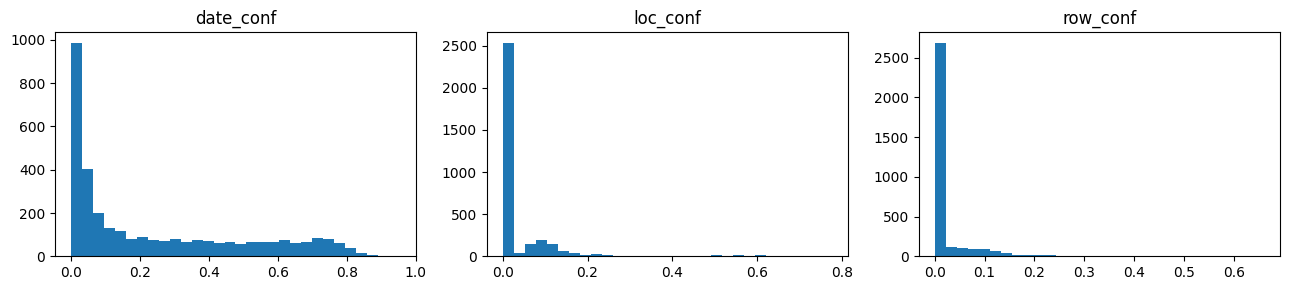


random sample:
           id verbatimDate  date_conf verbatimLocality  loc_conf
587   1743846      19/8/97   0.022611       KØBENHAVNS  0.005219
33    1728563         2013   0.003596       KØBENHAVNS  0.005119
891   1709884     17/05/89   0.020651       KØBENHAVNS  0.005414
3085  1742776         2017   0.006806       KØBENHAVNS  0.006412
1148  1709803     9-5-1977   0.022117  j. t. skovgaard  0.008635
2055  1707890  8. 10. 2007   0.055263        Haldgaard  0.005623
2541  1744535         2013   0.008599       KØBENHAVNS  0.005051
581   1707880   2016.01.16   0.023421       copenhagen  0.062582

CSV outputs in /kaggle/working : ['production_predictions.csv', 'submission.csv', 'results.csv']


In [21]:
# ==================== SANITY CHECKS & SUMMARY ====================
n = len(results_df)
print("images processed        :", n)
print("date MISSING            : %.1f%%" % (100 * (results_df["verbatimDate"] == "").mean()))
print("locality MISSING        : %.1f%%" % (100 * (results_df["verbatimLocality"] == "").mean()))
print("errors                  :", int((results_df["error"] != "").sum()))
print("date_conf   min/med/max : %.3f / %.3f / %.3f" % (
    results_df["date_conf"].min(), results_df["date_conf"].median(), results_df["date_conf"].max()))
print("loc_conf    min/med/max : %.3f / %.3f / %.3f" % (
    results_df["loc_conf"].min(), results_df["loc_conf"].median(), results_df["loc_conf"].max()))
assert results_df["date_conf"].std() > 0, "date confidence has no variance!"
assert results_df["loc_conf"].std() > 0, "loc confidence has no variance!"

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 3, figsize=(13, 3))
    ax[0].hist(results_df["date_conf"], bins=30); ax[0].set_title("date_conf")
    ax[1].hist(results_df["loc_conf"], bins=30); ax[1].set_title("loc_conf")
    ax[2].hist(results_df["row_conf"], bins=30); ax[2].set_title("row_conf")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("(plot skipped:", e, ")")

print("\nrandom sample:")
print(results_df.sample(min(8, n), random_state=0)[
    ["id", "verbatimDate", "date_conf", "verbatimLocality", "loc_conf"]].to_string())
print("\nCSV outputs in", OUTPUT_DIR, ":",
      [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".csv")])